# Аналог DeepDream с нуля

Цель: построить простой аналог DeepDream как генеративную систему.


In [1]:
# 1. Импорты и базовые настройки
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import gc

print("TensorFlow:", tf.__version__)
print("Устройства:", tf.config.list_physical_devices())

TensorFlow: 2.20.0
Устройства: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
MAX_SIZE = 448

# Слой, варианты: mixed3, mixed4, mixed5, mixed6, mixed7
# Фильтры внутри выбранного слоя
# Количество шагов и сила одного шага
LAYER_NAMES = ["mixed7"]
FILTERS = [70]
STEPS = 300
STEP_SIZE = 0.01
# промежуточный результат каждые N шагов
SHOW_EVERY = 100

Saving пример2.jpg to пример2.jpg
Файл загружен: пример2.jpg
Размер после уменьшения: (448, 448)


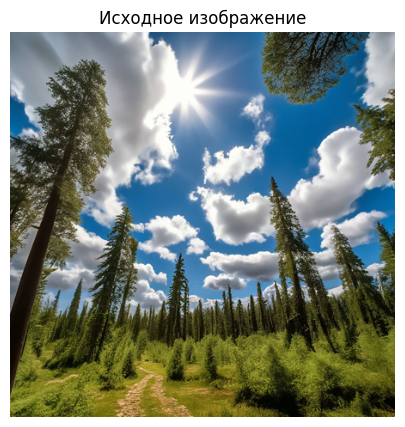

In [3]:
# 3. Загрузка изображения без искажения пропорций
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
print("Файл загружен:", img_path)

original_pil = Image.open(img_path).convert("RGB")

w, h = original_pil.size

if w > h:
    new_w = MAX_SIZE
    new_h = int(h * MAX_SIZE / w)
else:
    new_h = MAX_SIZE
    new_w = int(w * MAX_SIZE / h)

original_pil = original_pil.resize((new_w, new_h))
print("Размер после уменьшения:", original_pil.size)

original_np = np.array(original_pil).astype(np.float32) / 255.0

plt.figure(figsize=(8, 5))
plt.imshow(original_np)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

In [4]:
# 4. Сеть-оценщик признаков
base_model = tf.keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

outputs = [base_model.get_layer(name).output for name in LAYER_NAMES]

dream_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=outputs
)

print("Используемые слои:", LAYER_NAMES)
print("Фильтры:", FILTERS)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Используемые слои: ['mixed7']
Фильтры: [70]


In [5]:
# 5. Функции DeepDream

def calc_loss(image):
    prepared = tf.keras.applications.inception_v3.preprocess_input(image * 255.0)
    activations = dream_model(prepared)

    if not isinstance(activations, list):
        activations = [activations]

    loss = tf.constant(0.0)

    for activation in activations:
        channels_count = activation.shape[-1]

        for filter_id in FILTERS:
            if filter_id < channels_count:
                selected_channel = activation[:, :, :, filter_id]
                loss += tf.reduce_mean(selected_channel)

    return loss


@tf.function
def dream_step(image, step_size):
    with tf.GradientTape() as tape:
        tape.watch(image)
        loss = calc_loss(image)

    gradients = tape.gradient(loss, image)
    gradients = gradients / (tf.math.reduce_std(gradients) + 1e-8)

    image.assign_add(gradients * step_size)
    image.assign(tf.clip_by_value(image, 0.0, 1.0))

    return loss

Шаг: 0 loss: 0.09256549924612045
Шаг: 100 loss: 7.886397361755371
Шаг: 200 loss: 9.569188117980957
Шаг: 300 loss: 10.519267082214355


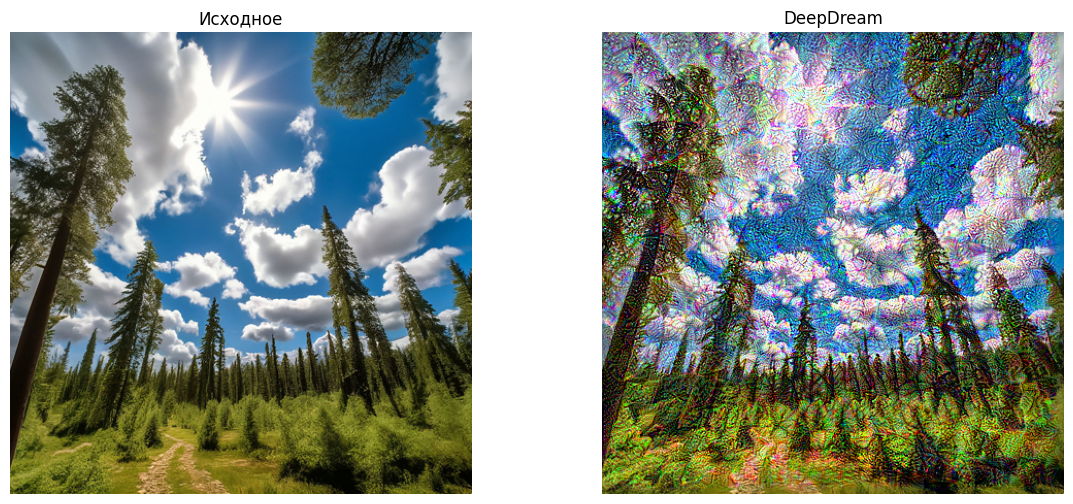

5039

In [6]:
# 6. Запуск DeepDream
img = tf.Variable(original_np[None, ...])

for step in range(STEPS + 1):
    loss = dream_step(img, STEP_SIZE)

    if step % SHOW_EVERY == 0:
        print("Шаг:", step, "loss:", float(loss))

result = img[0].numpy()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_np)
plt.title("Исходное")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("DeepDream")
plt.axis("off")

plt.show()

gc.collect()

Фильтр: 15
Фильтр: 70


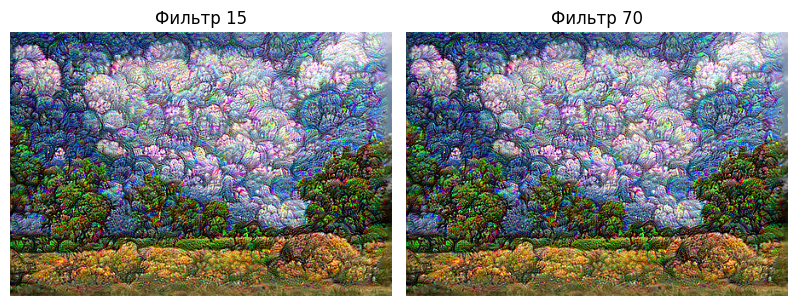

In [ ]:
# 8. Автоматический перебор фильтров
# Запускается после создания модели, по желанию

FILTERS_TO_TEST = [15, 70]
PREVIEW_STEPS = 300
PREVIEW_STEP_SIZE = 0.01

preview_results = []

for filter_id in FILTERS_TO_TEST:
    print("Фильтр:", filter_id)

    FILTERS = [filter_id]
    img_preview = tf.Variable(original_np[None, ...])

    for step in range(PREVIEW_STEPS):
        _ = dream_step(img_preview, PREVIEW_STEP_SIZE)

    preview_results.append((filter_id, img_preview[0].numpy()))
    gc.collect()

cols = 4
rows = int(np.ceil(len(preview_results) / cols))

plt.figure(figsize=(16, rows * 4))

for i, (filter_id, preview_img) in enumerate(preview_results):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(preview_img)
    plt.title(f"Фильтр {filter_id}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Генерация DeepDream с сохранением значений для графиков

loss_history = []
difference_history = []

original_tensor = tf.identity(img)

for step in range(STEPS):
    loss = dream_step(img, STEP_SIZE)

    difference = tf.reduce_mean(tf.abs(img - original_tensor))

    loss_history.append(float(loss))
    difference_history.append(float(difference))

    if step % 50 == 0:
        print(
            f"Шаг {step} | "
            f"loss = {float(loss):.4f} | "
            f"отличие от исходного = {float(difference):.4f}"
        )

Шаг 0 | loss = 10.6113 | отличие от исходного = 0.0071
Шаг 50 | loss = 10.9247 | отличие от исходного = 0.0226
Шаг 100 | loss = 11.2305 | отличие от исходного = 0.0359
Шаг 150 | loss = 11.5079 | отличие от исходного = 0.0474
Шаг 200 | loss = 11.7369 | отличие от исходного = 0.0578
Шаг 250 | loss = 11.9699 | отличие от исходного = 0.0672


In [8]:
# Списки для хранения значений
loss_history = []
difference_history = []

# Сохраняем исходное изображение
original_tensor = tf.identity(img)

# Генерация с записью значений
for step in range(STEPS):
    loss = dream_step(img, STEP_SIZE)

    difference = tf.reduce_mean(tf.abs(img - original_tensor))

    loss_history.append(float(loss))
    difference_history.append(float(difference))

    if step % 50 == 0:
        print(
            f"Шаг {step} | "
            f"loss = {float(loss):.4f} | "
            f"отличие = {float(difference):.4f}"
        )

Шаг 0 | loss = 12.2388 | отличие = 0.0069
Шаг 50 | loss = 12.3628 | отличие = 0.0182
Шаг 100 | loss = 12.5025 | отличие = 0.0277
Шаг 150 | loss = 12.7001 | отличие = 0.0369
Шаг 200 | loss = 12.7885 | отличие = 0.0451
Шаг 250 | loss = 12.9614 | отличие = 0.0528


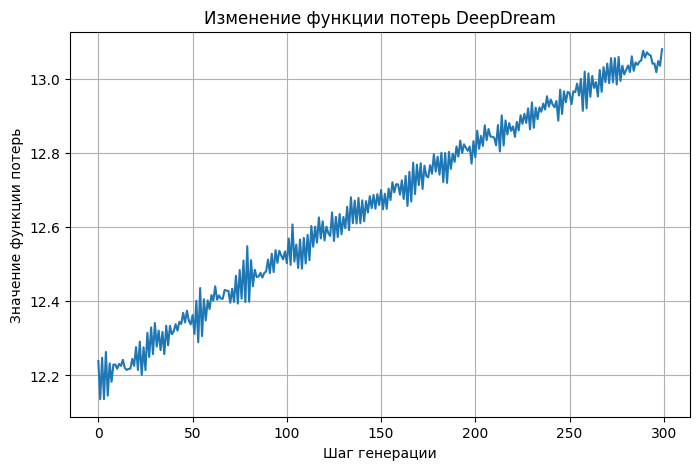

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Изменение функции потерь DeepDream")
plt.xlabel("Шаг генерации")
plt.ylabel("Значение функции потерь")
plt.grid(True)
plt.show()

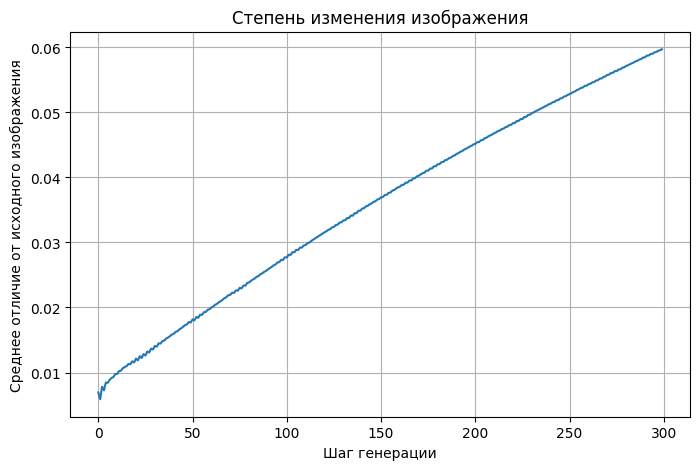

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(difference_history)
plt.title("Степень изменения изображения")
plt.xlabel("Шаг генерации")
plt.ylabel("Среднее отличие от исходного изображения")
plt.grid(True)
plt.show()